In [1]:
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', None)

# mbg = pd.read_csv(r'E:\Kuliah\Materi Tugas\Semester 8\TA\dataset-mbg.csv')
# mbg = pd.read_csv(r'E:\Kuliah\Materi Tugas\Semester 8\TA\dataset-mbg.csv')
# mbg = pd.read_csv(r'E:\Kuliah\Materi Tugas\Semester 8\TA\dataset bersih\ini-fix\augmentasi\dataset aug.csv')
mbg = pd.read_csv(r'E:\Kuliah\Materi Tugas\Semester 8\TA\dataset bersih\ini-fix\model\dataset baru\dataset-mbg - Copy 78.csv')

mbg.head()

,full_text,Sentimen,Gaya Bahasa
0,@lrstdw_ @sdenta Ini bergizi apanya anjing ga cocok disebut MBG juga,negatif,gaul
1,Sinergi pangan Kalteng melalui makan MBG https://t.co/NmDFBWmRNU,netral,formal
2,MBG tolol,negatif,gaul
3,@joyumnyang indo bisa nih bikin film zombie lagi tp asal mulanya dr mbg bukan jamu lagi,negatif,gaul
4,@regar_op0sisi hasil diplomasi internasional : -dapat utangan buat program MBG -dipuji sbg pemimpin cerdas karena sepakat tarif dan belanja pesawat dan hibah data demografi -dapat kapal induk bekas murmer -Indonesia jd dikenal sbg negara pendukung two state solution - sumbang hutan brazil,negatif,gaul


In [2]:
from collections import Counter

words = " ".join(mbg['full_text']).split()
Counter(words).most_common(200)

[('MBG', 2620),
 ('makan', 1816),
 ('dan', 1708),
 ('Makan', 1559),
 ('di', 1550),
 ('program', 1438),
 ('gratis', 1429),
 ('yang', 1414),
 ('yg', 1388),
 ('Bergizi', 1331),
 ('Gratis', 1266),
 ('bergizi', 1237),
 ('ini', 1064),
 ('mbg', 972),
 ('Program', 816),
 ('ada', 805),
 ('itu', 803),
 ('untuk', 773),
 ('dari', 708),
 ('anak', 689),
 ('ga', 588),
 ('aja', 579),
 ('buat', 568),
 ('bisa', 515),
 ('sekolah', 515),
 ('tapi', 504),
 ('@prabowo', 466),
 ('gizi', 466),
 ('gak', 464),
 ('ke', 461),
 ('jadi', 450),
 ('Prabowo', 421),
 ('Indonesia', 417),
 ('bukan', 407),
 ('keracunan', 404),
 ('dengan', 401),
 ('juga', 381),
 ('lebih', 375),
 ('banyak', 359),
 ('ya', 341),
 ('(MBG)', 341),
 ('makanan', 327),
 ('tidak', 322),
 ('sama', 302),
 ('mau', 301),
 ('nya', 288),
 ('karena', 279),
 ('kalo', 264),
 ('cuma', 261),
 ('susu', 261),
 ('pada', 251),
 ('orang', 244),
 ('bikin', 241),
 ('apa', 238),
 ('Presiden', 236),
 ('dalam', 234),
 ('#MakanBergiziGratis', 234),
 ('sehat', 228),
 ('pe

In [3]:
import re

# emoticon_dict = {
#     r":\)+": " emot_senang ",
#     r":\(+": " emot_sedih ",
#     r"(wkwk+|wk+wk+|ha(ha)+|awok(awok)+)": " ekspresi_tawa "
# }

def clean_text(text):
    # 7930
    text = text.lower()  
    text = re.sub(r'&amp;', 'dan', text) 
    # text = re.sub(r'\bmbg\b', 'makan bergizi gratis', text) 
    text = re.sub(r'badan gizi nasional', 'bgn', text) 
    text = re.sub(r'makan bergizi gratis', 'mbg', text) 
    # text = re.sub(r'\b(\w+)\s+\1\b', r'\1', text) 
    
    text = re.sub(r'([a-zA-Z]+)2([a-zA-Z]*)', r'\1 \1\2', text) 
    text = re.sub(r'\b(\w+)\s+\1\b', r'\1', text) 
    text = re.sub(r'https?://\S+|www\.\S+', '', text) 
    text = re.sub(r'@\w+', '', text) 
    text = re.sub(r'#\w+', '', text) 
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) 
    text = re.sub(r'\b[a-zA-Z]{1}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text.strip()


mbg['text_gaya'] = mbg['full_text'].apply(clean_text)

# mbg.head(200)
display(mbg.head(50))


,full_text,Sentimen,Gaya Bahasa,text_gaya
0,@lrstdw_ @sdenta Ini bergizi apanya anjing ga cocok disebut MBG juga,negatif,gaul,ini bergizi apanya anjing ga cocok disebut mbg juga
1,Sinergi pangan Kalteng melalui makan MBG https://t.co/NmDFBWmRNU,netral,formal,sinergi pangan kalteng melalui makan mbg
2,MBG tolol,negatif,gaul,mbg tolol
3,@joyumnyang indo bisa nih bikin film zombie lagi tp asal mulanya dr mbg bukan jamu lagi,negatif,gaul,indo bisa nih bikin film zombie lagi tp asal mulanya dr mbg bukan jamu lagi
4,@regar_op0sisi hasil diplomasi internasional : -dapat utangan buat program MBG -dipuji sbg pemimpin cerdas karena sepakat tarif dan belanja pesawat dan hibah data demografi -dapat kapal induk bekas murmer -Indonesia jd dikenal sbg negara pendukung two state solution - sumbang hutan brazil,negatif,gaul,hasil diplomasi internasional dapat utangan buat program mbg dipuji sbg pemimpin cerdas karena sepakat tarif dan belanja pesawat dan hibah data demografi dapat kapal induk bekas murmer indonesia jd dikenal sbg negara pendukung two state solution sumbang hutan brazil
5,@yusuf_dumdum @prabowo @Gerindra kalau pas liburan mbg di stop utk bayar cicilan mobil box gimana?,negatif,informal,kalau pas liburan mbg di stop utk bayar cicilan mobil box gimana
6,ini gw pagi2 lagi gibahin kebobrokan mbg bener2 dzolim ya Allah,negatif,gaul,ini gw pagi lagi gibahin kebobrokan mbg bener dzolim ya allah
7,@dosenkesmas @piyopikavet MBG dihentikan aja deh kasihan orang2nya jadi kebanyakan dosa,negatif,informal,mbg dihentikan aja deh kasihan orang orangnya jadi kebanyakan dosa
8,@kangwaqfi2 Apa an tadi adik ku aja libur dapur mbg nya lagi selametan hahaha,netral,gaul,apa an tadi adik ku aja libur dapur mbg nya lagi selametan hahaha
9,@SumandoGaek Yg bener cuma satu doang dari sekian banyak janji yaitu MBG makan gaji buta https://t.co/ksIAADf2qr,negatif,gaul,yg bener cuma satu doang dari sekian banyak janji yaitu mbg makan gaji buta ksiaadfqr


In [4]:
from collections import Counter

words = " ".join(mbg['text_gaya']).split()
Counter(words).most_common(1000)

[('mbg', 6683),
 ('program', 2320),
 ('dan', 1959),
 ('di', 1662),
 ('yang', 1507),
 ('yg', 1469),
 ('anak', 1380),
 ('ini', 1344),
 ('makan', 1264),
 ('itu', 927),
 ('gratis', 925),
 ('ada', 910),
 ('untuk', 819),
 ('dari', 772),
 ('sekolah', 694),
 ('ga', 662),
 ('gizi', 646),
 ('aja', 644),
 ('tapi', 603),
 ('buat', 602),
 ('prabowo', 597),
 ('bisa', 564),
 ('indonesia', 554),
 ('gak', 536),
 ('ya', 525),
 ('jadi', 520),
 ('keracunan', 512),
 ('ke', 476),
 ('bukan', 470),
 ('presiden', 465),
 ('bergizi', 453),
 ('dengan', 452),
 ('lebih', 430),
 ('banyak', 419),
 ('juga', 405),
 ('makanan', 402),
 ('tidak', 373),
 ('mau', 362),
 ('kalo', 357),
 ('pemerintah', 356),
 ('apa', 355),
 ('nya', 354),
 ('susu', 353),
 ('sama', 343),
 ('orang', 320),
 ('rakyat', 319),
 ('karena', 314),
 ('pak', 296),
 ('kerja', 284),
 ('kalau', 283),
 ('cuma', 282),
 ('kan', 270),
 ('negara', 265),
 ('pada', 265),
 ('udah', 263),
 ('kita', 263),
 ('sehat', 260),
 ('bikin', 258),
 ('dapur', 249),
 ('mereka',

In [5]:
from collections import Counter
from nltk.tokenize import word_tokenize

counter = Counter()

for text in mbg['full_text']:
    tokens = word_tokenize(text)
    for i in range(len(tokens)-1):
        if tokens[i] == 'tidak':
            counter[f"tidak {tokens[i+1]}"] += 1

print(counter.most_common(100))

[('tidak ada', 43), ('tidak hanya', 13), ('tidak bergizi', 12), ('tidak perlu', 12), ('tidak bisa', 10), ('tidak boleh', 8), ('tidak akan', 7), ('tidak layak', 7), ('tidak tepat', 6), ('tidak di', 6), ('tidak mau', 6), ('tidak dipaksakan', 5), ('tidak keracunan', 5), ('tidak gratis', 5), ('tidak sesuai', 5), ('tidak kalah', 4), ('tidak terlalu', 3), ('tidak sehat', 3), ('tidak punya', 3), ('tidak suka', 3), ('tidak ?', 3), ('tidak mampu', 3), ('tidak butuh', 3), ('tidak ikut', 2), ('tidak paham', 2), ('tidak tau', 2), ('tidak bersyukur', 2), ('tidak anti', 2), ('tidak lebih', 2), ('tidak salah', 2), ('tidak pernah', 2), ('tidak bertanggung', 2), ('tidak semuanya', 2), ('tidak berjalan', 2), ('tidak memberi', 2), ('tidak semua', 2), ('tidak sadar', 2), ('tidak terulang', 2), ('tidak aman', 2), ('tidak lagi', 2), ('tidak dibutuhkan', 2), ('tidak melibatkan', 2), ('tidak ingin', 2), ('tidak menghapus', 2), ('tidak terjadi', 2), ('tidak memenuhi', 2), ('tidak seimbang', 1), ('tidak upload'

In [6]:
# from nltk.tokenize import word_tokenize
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
# import nltk
# nltk.download('punkt', download_dir=r'E:\Kuliah\Materi Tugas\Semester 8\nltk_data')

In [7]:
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# # Setup stemmer
# factory_stem = StemmerFactory()
# stem = factory_stem.get_words()
# stemmer = factory_stem.create_stemmer()
# print(stem)

# Setup stopword
# factory_stop = StopWordRemoverFactory()
# stopword_list = factory_stop.get_stop_words()
# stopword = factory_stop.create_stop_word_remover()

In [8]:
positive_words = {
    "baik",
    "bagus",
    "keren",
    "sehat",
    "dukung",
    "bantu",
    "manfaat",
    "cerdas",
    "kualitas",
    "emas",
    "prioritas",
    "kuat",
    "investasi",
    "komitmen",
    "bangun",
    "wujud",
    "tumbuh",
    "tingkat",
    "maju",
    "benar",
    "layak",
    "efektif",
    "optimal",
    "sukses",
    "hebat",
    "mantap",
    "hasil",
    "unggul",
    "tepat",
    "efektif",
    "suka",
    "penting",
    "guna",
    "sesuai"
}

negative_words = {
    "racun",
    "korupsi",
    "masalah",
    "khawatir",
    "kasus",
    "korban",
    "stop",
    "proyek",
    "mubazir",
    "jelek",
    "buruk",
    "gagal",
    "bahaya",
    "otak",
    "curang",
    "sampah",
    "bodoh",
    "cacat",
    "rugi",
}

neutral_words = {
    "mbg",
    "program",
    "anak",
    "gizi",
    "makan",
    "sekolah",
    "presiden",
    "prabowo",
    "gibran",
    "indonesia",
    "dapur",
    "menu",
    "siswa",
    "bgn",
    "rakyat",
    "negara"
}

In [9]:
def handle_negation(tokens):
    negation = {"tidak", "bukan", "belum", "jangan", "tanpa", "kurang"}
    result = []
    i = 0

    while i < len(tokens):
        if tokens[i] in negation and i + 1 < len(tokens):

            gabung = tokens[i] + "_" + tokens[i + 1]
            result.append(gabung)
            i += 2 
        else:
            result.append(tokens[i])
            i += 1
    
    return result

In [10]:
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import nltk
# nltk.download('punkt', download_dir=r'E:\Kuliah\Materi Tugas\Semester 8\nltk_data')


normalization_dict = {
    "yg": "yang",
    "ga": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "g": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "engga": "tidak",
    "kaga": "tidak",
    "tdk": "tidak",
    
    "aja": "saja",
    "doang": "saja",
    "kalo": "kalau",
    "klo": "kalau",
    "tp": "tapi",
    "jd": "jadi",
    "jg": "juga",
    "dr": "dari",
    "dri": "dari",
    "dgn": "dengan",
    "dg": "dengan",
    "krn": "karena",
    "karna": "karena",
    "utk": "untuk",
    "pd": "pada",
    "sbg": "sebagai",
    "dlm": "dalam",
    
    "udah": "sudah",
    "udh": "sudah",
    "sdh": "sudah",
    "dah": "sudah",
    
    "blm": "belum",
    
    "hrs": "harus",
    "bgt": "banget",
    "bnyk": "banyak",
    "trs": "terus",
    "trus": "terus",
    "bs": "bisa",
    "lg": "lagi",
    "msh": "masih",
    "drpd": "daripada",
    "pdhl": "padahal",
    
    "knp": "kenapa",
    "gmn": "bagaimana",
    
    "skrg": "sekarang",
    "tau": "tahu",
    "liat": "lihat",
    "dpt": "dapat",
    "dapet": "dapat",
    "pake": "pakai",
    
    "bikin": "buat",
    "ngasih": "beri",
    
    "kayak": "seperti",
    "gini": "begini",
    "gitu": "begitu",
    "sampe": "sampai",
    "emang": "memang",
    "bener": "benar",
    "mending": "lebih baik",
    
    "gue": "saya",
    "gw": "saya",
    "w": "saya",
    "gua": "saya",
    "lu": "kamu",
    "lo": "kamu",
    
    "org": "orang",
    "duit": "uang"
    }

stopwords_dict = [
    "saja","ya","kan","tuh","nih","sih","kok","lah","mah","nya","dong","deh"
]

important_dict = [
    "tidak", "belum", "bukan", "jangan", "tanpa", "harus", "bisa", "dapat", "ingin", "mengapa", "kenapa", "kurang", "guna"
]


#setup stemmer
factory_stem = StemmerFactory()
# stem = factory_stem.get_words()
stemmer = factory_stem.create_stemmer()

#setup stopword
factory_stop = StopWordRemoverFactory()
stopword_list = factory_stop.get_stop_words()
stopword_list = stopword_list + stopwords_dict
# stopword = factory_stop.create_stop_word_remover()

for word in important_dict:
    if word in stopword_list:
        stopword_list.remove(word)

def prepro_sentimen(text): 
    #tokenisasi
    tokens = word_tokenize(text)

    #normalisasi
    tokens = [normalization_dict[word] if word in normalization_dict else word for word in tokens]
    
    #stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # negasi handling
    tokens = handle_negation(tokens)
    
    #stopword removal
    tokens = [word for word in tokens if word not in stopword_list]
    
    return " ".join(tokens)

mbg['text_sentimen'] = mbg['text_gaya'].apply(prepro_sentimen)
mbg.head(50)

,full_text,Sentimen,Gaya Bahasa,text_gaya,text_sentimen
0,@lrstdw_ @sdenta Ini bergizi apanya anjing ga cocok disebut MBG juga,negatif,gaul,ini bergizi apanya anjing ga cocok disebut mbg juga,gizi apa anjing tidak_cocok sebut mbg
1,Sinergi pangan Kalteng melalui makan MBG https://t.co/NmDFBWmRNU,netral,formal,sinergi pangan kalteng melalui makan mbg,sinergi pangan kalteng lalu makan mbg
2,MBG tolol,negatif,gaul,mbg tolol,mbg tolol
3,@joyumnyang indo bisa nih bikin film zombie lagi tp asal mulanya dr mbg bukan jamu lagi,negatif,gaul,indo bisa nih bikin film zombie lagi tp asal mulanya dr mbg bukan jamu lagi,indo bisa buat film zombie asal mula mbg bukan_jamu
4,@regar_op0sisi hasil diplomasi internasional : -dapat utangan buat program MBG -dipuji sbg pemimpin cerdas karena sepakat tarif dan belanja pesawat dan hibah data demografi -dapat kapal induk bekas murmer -Indonesia jd dikenal sbg negara pendukung two state solution - sumbang hutan brazil,negatif,gaul,hasil diplomasi internasional dapat utangan buat program mbg dipuji sbg pemimpin cerdas karena sepakat tarif dan belanja pesawat dan hibah data demografi dapat kapal induk bekas murmer indonesia jd dikenal sbg negara pendukung two state solution sumbang hutan brazil,hasil diplomasi internasional dapat utang buat program mbg puji bagai pimpin cerdas sepakat tarif belanja pesawat hibah data demografi dapat kapal induk bekas murmer indonesia jadi kenal bagai negara dukung two state solution sumbang hutan brazil
5,@yusuf_dumdum @prabowo @Gerindra kalau pas liburan mbg di stop utk bayar cicilan mobil box gimana?,negatif,informal,kalau pas liburan mbg di stop utk bayar cicilan mobil box gimana,kalau pas libur mbg stop bayar cicil mobil box gimana
6,ini gw pagi2 lagi gibahin kebobrokan mbg bener2 dzolim ya Allah,negatif,gaul,ini gw pagi lagi gibahin kebobrokan mbg bener dzolim ya allah,pagi gibahin bobrok mbg benar dzolim allah
7,@dosenkesmas @piyopikavet MBG dihentikan aja deh kasihan orang2nya jadi kebanyakan dosa,negatif,informal,mbg dihentikan aja deh kasihan orang orangnya jadi kebanyakan dosa,mbg henti kasihan orang orang jadi banyak dosa
8,@kangwaqfi2 Apa an tadi adik ku aja libur dapur mbg nya lagi selametan hahaha,netral,gaul,apa an tadi adik ku aja libur dapur mbg nya lagi selametan hahaha,apa an tadi adik ku libur dapur mbg selametan hahaha
9,@SumandoGaek Yg bener cuma satu doang dari sekian banyak janji yaitu MBG makan gaji buta https://t.co/ksIAADf2qr,negatif,gaul,yg bener cuma satu doang dari sekian banyak janji yaitu mbg makan gaji buta ksiaadfqr,benar cuma satu sekian banyak janji mbg makan gaji buta ksiaadfqr


In [11]:
from collections import Counter
from nltk.tokenize import word_tokenize

counter = Counter()

for text in mbg['text_sentimen']:
    tokens = word_tokenize(text)
    for i in range(len(tokens)-1):
        if tokens[i] == 'tanpa':
            counter[f"tanpa {tokens[i+1]}"] += 1

print(counter.most_common(10))

[]


In [12]:
contoh = [
    "program bergizi",
    "tidak jelek",
    "khawatir",
    "mengkhawatirkan",
    "bagus",
    "tidak bagus",
    "bermanfaat",
    "tidak bermanfaat",
    "gizi",
    "program",
    "mbg",
    "ga ngotak"
    
]

for c in contoh:
    print(c, "->", prepro_sentimen(c))

program bergizi -> program gizi
tidak jelek -> tidak_jelek
khawatir -> khawatir
mengkhawatirkan -> khawatir
bagus -> bagus
tidak bagus -> tidak_bagus
bermanfaat -> manfaat
tidak bermanfaat -> tidak_manfaat
gizi -> gizi
program -> program
mbg -> mbg
ga ngotak -> tidak_ngotak


In [13]:
words = " ".join(mbg['text_sentimen']).split()
Counter(words).most_common(500)

[('mbg', 6618),
 ('program', 2381),
 ('makan', 1691),
 ('anak', 1476),
 ('gizi', 1105),
 ('gratis', 932),
 ('buat', 919),
 ('jadi', 821),
 ('kalau', 741),
 ('sekolah', 725),
 ('racun', 608),
 ('prabowo', 596),
 ('indonesia', 556),
 ('lebih', 544),
 ('bisa', 541),
 ('banyak', 497),
 ('presiden', 477),
 ('dapat', 449),
 ('baik', 435),
 ('perintah', 411),
 ('kerja', 410),
 ('apa', 407),
 ('orang', 407),
 ('sama', 397),
 ('susu', 394),
 ('sehat', 393),
 ('nyata', 368),
 ('rakyat', 336),
 ('mau', 334),
 ('harus', 331),
 ('dukung', 317),
 ('banget', 312),
 ('hari', 294),
 ('pak', 291),
 ('kamu', 285),
 ('terus', 282),
 ('kasih', 282),
 ('memang', 276),
 ('negara', 275),
 ('menu', 273),
 ('beri', 263),
 ('anggar', 262),
 ('dapur', 257),
 ('benar', 249),
 ('jalan', 245),
 ('gibran', 239),
 ('bgn', 239),
 ('uang', 238),
 ('didik', 237),
 ('siang', 235),
 ('satu', 234),
 ('cuma', 233),
 ('siswa', 233),
 ('masa', 233),
 ('semua', 228),
 ('kata', 223),
 ('malah', 223),
 ('lanjut', 222),
 ('makin',

In [14]:
word_counts = Counter(words)

rare_words = [word for word, count in word_counts.items() if count < 5]

Counter(rare_words).most_common(500)
# Counter(rare_words)[:500]

[('tidak_cocok', 1),
 ('kalteng', 1),
 ('zombie', 1),
 ('mula', 1),
 ('bukan_jamu', 1),
 ('diplomasi', 1),
 ('pesawat', 1),
 ('hibah', 1),
 ('demografi', 1),
 ('kapal', 1),
 ('induk', 1),
 ('murmer', 1),
 ('two', 1),
 ('state', 1),
 ('solution', 1),
 ('brazil', 1),
 ('cicil', 1),
 ('box', 1),
 ('gibahin', 1),
 ('selametan', 1),
 ('ksiaadfqr', 1),
 ('damkar', 1),
 ('rejeki', 1),
 ('jangan_hijau', 1),
 ('tidak_bakar', 1),
 ('haaa', 1),
 ('gimanaaa', 1),
 ('responku', 1),
 ('qoutes', 1),
 ('kwowkwoowkw', 1),
 ('ngehasilin', 1),
 ('babu', 1),
 ('geser', 1),
 ('bisnisin', 1),
 ('argorejo', 1),
 ('dayu', 1),
 ('role', 1),
 ('hiu', 1),
 ('sedot', 1),
 ('payung', 1),
 ('patronase', 1),
 ('stroberi', 1),
 ('sarang', 1),
 ('nyiapin', 1),
 ('menuh', 1),
 ('hadehhhhhhh', 1),
 ('eettdaahhhh', 1),
 ('pergi', 1),
 ('atm', 1),
 ('keruk', 1),
 ('lempar', 1),
 ('muas', 1),
 ('sowan', 1),
 ('tidak_basi', 1),
 ('ump', 1),
 ('ngetik', 1),
 ('np', 1),
 ('riskan', 1),
 ('tidak_ambil', 1),
 ('aktivis', 1),
 (

In [15]:
print("Sebelum:", len(mbg))

mbg = mbg.drop_duplicates(subset='text_gaya', keep='last')

print("Sesudah:", len(mbg))


# print("Sebelum:", len(mbg))

# mbg = mbg.drop_duplicates(subset='text_sentimen', keep='last')

# print("Sesudah:", len(mbg))

Sebelum: 6075
Sesudah: 6037


In [16]:
mbg[mbg['text_gaya'].duplicated(keep=False)].sort_values('text_gaya')


,full_text,Sentimen,Gaya Bahasa,text_gaya,text_sentimen


In [17]:
mbg = mbg.drop_duplicates(subset='text_gaya', keep='last')

In [18]:
mbg[mbg['text_gaya'].duplicated(keep=False)].sort_values('text_gaya')

,full_text,Sentimen,Gaya Bahasa,text_gaya,text_sentimen


In [19]:
print(mbg.shape[0])

6037


In [20]:
print(len(mbg))

6037


In [21]:
print("Sebelum:", len(mbg))

mbg = mbg.drop_duplicates(subset='text_sentimen', keep='last')

print("Sesudah:", len(mbg))

Sebelum: 6037
Sesudah: 6024


In [22]:
mbg[mbg['text_sentimen'].duplicated(keep=False)].sort_values('text_sentimen')

,full_text,Sentimen,Gaya Bahasa,text_gaya,text_sentimen


In [23]:
# mbg[mbg['text_sentimen'].duplicated(keep=False)].sort_values('text_sentimen')


In [24]:
print(mbg.shape[0])

6024


In [25]:
print("data null \n", mbg.isnull().sum())
print("data kosong \n ", mbg.empty)
print("data nan \n ", mbg.isna().sum())

data null 
 full_text        0
Sentimen         0
Gaya Bahasa      0
text_gaya        0
text_sentimen    0
dtype: int64
data kosong 
  False
data nan 
  full_text        0
Sentimen         0
Gaya Bahasa      0
text_gaya        0
text_sentimen    0
dtype: int64


In [26]:
mbg[mbg['text_sentimen'].str.strip() == ""]
mbg[mbg['text_gaya'].str.strip() == ""]

print((mbg['text_sentimen'].str.strip() == "").sum())
print((mbg['text_gaya'].str.strip() == "").sum())

0
0


In [27]:
mbg = mbg[mbg['text_sentimen'].notna()]
mbg = mbg[mbg['text_sentimen'].str.strip() != ""]

In [28]:
mbg[mbg['text_sentimen'].str.strip() == ""]
mbg[mbg['text_gaya'].str.strip() == ""]

print((mbg['text_sentimen'].str.strip() == "").sum())
print((mbg['text_gaya'].str.strip() == "").sum())

0
0


In [29]:
mbg[mbg.isnull().any(axis=1)]

,full_text,Sentimen,Gaya Bahasa,text_gaya,text_sentimen


In [30]:
mbg.info()
# mbg.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6024 entries, 0 to 6074
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   full_text      6024 non-null   object
 1   Sentimen       6024 non-null   object
 2   Gaya Bahasa    6024 non-null   object
 3   text_gaya      6024 non-null   object
 4   text_sentimen  6024 non-null   object
dtypes: object(5)
memory usage: 282.4+ KB


In [31]:
mbg.describe()

,full_text,Sentimen,Gaya Bahasa,text_gaya,text_sentimen
count,6024,6024,6024,6024,6024
unique,6024,3,3,6024,6024
top,@lrstdw_ @sdenta Ini bergizi apanya anjing ga cocok disebut MBG juga,negatif,informal,ini bergizi apanya anjing ga cocok disebut mbg juga,gizi apa anjing tidak_cocok sebut mbg
freq,1,3070,3143,1,1


In [32]:
mbg[mbg['text_sentimen'] == 'mbg']

,full_text,Sentimen,Gaya Bahasa,text_gaya,text_sentimen
4698,@RagilSemar MBG juga?,netral,informal,mbg juga,mbg


In [33]:
print(mbg['Sentimen'].unique())
print(mbg['Gaya Bahasa'].unique())

['negatif' 'netral' 'positif']
['gaul' 'formal' 'informal']


In [34]:
mbg['Sentimen'].unique()
mbg['Gaya Bahasa'].unique()

array(['gaul', 'formal', 'informal'], dtype=object)

In [35]:
mbg['Gaya Bahasa'].unique()

array(['gaul', 'formal', 'informal'], dtype=object)

In [36]:
mbg['Sentimen'].value_counts()

Sentimen
negatif    3070
positif    1606
netral     1348
Name: count, dtype: int64

<Axes: xlabel='Sentimen'>

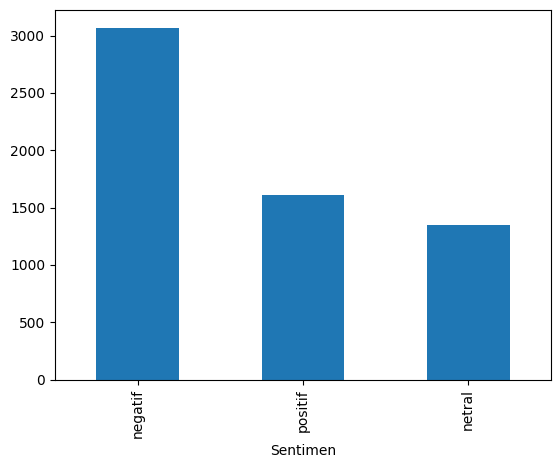

In [37]:
mbg['Sentimen'].value_counts().plot(kind='bar')

In [38]:
mbg['Gaya Bahasa'].value_counts()

Gaya Bahasa
informal    3143
formal      1482
gaul        1399
Name: count, dtype: int64

<Axes: xlabel='Gaya Bahasa'>

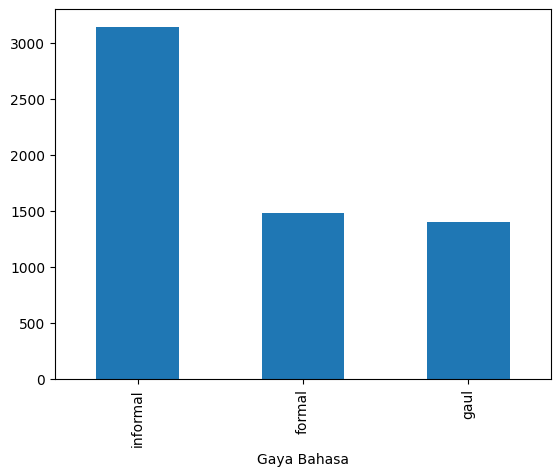

In [39]:
mbg['Gaya Bahasa'].value_counts().plot(kind='bar')

In [40]:
mbg.to_csv(r'E:\Kuliah\Materi Tugas\Semester 8\TA\dataset bersih\ini-fix\negasi\final\dataset_mbg_final.csv', index=False)
# mbg_clean.to_csv(r'E:\Kuliah\Materi Tugas\Semester 8\TA\prepo\mbg_preprocessing_fullsingkatan.csv', index=False)
